In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"/content/diabetes_risk_dataset_text_labels.csv")

In [2]:
data.head()

,Age,BMI,Blood Pressure,Physical Activity (hours/week),Family History,Smoking Status,Diabetes Risk
0,48.0,19.260848,124.704947,1.756909,Yes,No,1
1,62.0,31.038294,122.348977,1.152586,Yes,No,1
2,66.0,29.817199,138.333535,0.000000,No,No,1
3,62.0,26.940032,136.166399,0.328125,Yes,Yes,1
4,38.0,25.759267,125.547778,4.683819,Yes,No,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             950 non-null    float64
 1   BMI                             950 non-null    float64
 2   Blood Pressure                  950 non-null    float64
 3   Physical Activity (hours/week)  950 non-null    float64
 4   Family History                  950 non-null    object 
 5   Smoking Status                  950 non-null    object 
 6   Diabetes Risk                   1000 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [4]:
data.isna().sum()

,0
Age,50
BMI,50
Blood Pressure,50
Physical Activity (hours/week),50
Family History,50
Smoking Status,50
Diabetes Risk,0


In [5]:
null_columns = ["Age" , "BMI" , "Blood Pressure" , "Physical Activity (hours/week)" , "Family History" , "Smoking Status"]
for col in null_columns:
    if data[col].dtype.name == "object" :
        data[col] = data[col].fillna(data[col].mode()[0])
    elif data[col].dtype.name in ["float64" , "int64"]:
        data[col] = data[col].fillna(data[col].median())

In [6]:
data.isna().sum()

,0
Age,0
BMI,0
Blood Pressure,0
Physical Activity (hours/week),0
Family History,0
Smoking Status,0
Diabetes Risk,0


In [7]:
from sklearn.preprocessing import LabelEncoder
cat_columns = ["Family History" , "Smoking Status" ]
le = {}
for col in cat_columns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

In [8]:
data.head()

,Age,BMI,Blood Pressure,Physical Activity (hours/week),Family History,Smoking Status,Diabetes Risk
0,48.0,19.260848,124.704947,1.756909,1,0,1
1,62.0,31.038294,122.348977,1.152586,1,0,1
2,66.0,29.817199,138.333535,0.000000,0,0,1
3,62.0,26.940032,136.166399,0.328125,1,1,1
4,38.0,25.759267,125.547778,4.683819,1,0,0


In [9]:
from sklearn.preprocessing import StandardScaler
num_columns = ["Age" , "BMI" , "Blood Pressure" , "Physical Activity (hours/week)"]
scale = StandardScaler()
data[num_columns] = scale.fit_transform(data[num_columns])

In [10]:
data.head()

,Age,BMI,Blood Pressure,Physical Activity (hours/week),Family History,Smoking Status,Diabetes Risk
0,0.277768,-1.286139,0.040815,-0.401157,1,0,1
1,1.311460,0.988713,-0.109923,-0.830442,1,0,1
2,1.606801,0.752854,0.912794,-1.649187,0,0,1
3,1.311460,0.197120,0.774138,-1.416102,1,1,1
4,-0.460584,-0.030949,0.094741,1.677990,1,0,0


In [11]:
summary = data.describe()
print(summary)

                Age           BMI  Blood Pressure  \
count  1.000000e+03  1.000000e+03    1.000000e+03   
mean   3.641532e-17  1.882938e-16   -3.144152e-16   
std    1.000500e+00  1.000500e+00    1.000500e+00   
min   -1.937287e+00 -1.915982e+00   -2.179663e+00   
25%   -7.005480e-01 -7.714739e-01   -6.801356e-01   
50%   -1.757277e-02 -1.108066e-01   -9.692932e-02   
75%    7.207788e-01  6.797536e-01    5.932495e-01   
max    2.640493e+00  2.862377e+00    3.578682e+00   

       Physical Activity (hours/week)  Family History  Smoking Status  \
count                    1.000000e+03     1000.000000     1000.000000   
mean                     6.039613e-17        0.433000        0.267000   
std                      1.000500e+00        0.495739        0.442614   
min                     -1.649187e+00        0.000000        0.000000   
25%                     -8.022365e-01        0.000000        0.000000   
50%                     -1.004464e-01        0.000000        0.000000   
75%        

Text(0.5, 1.0, 'Distribution of patient age')

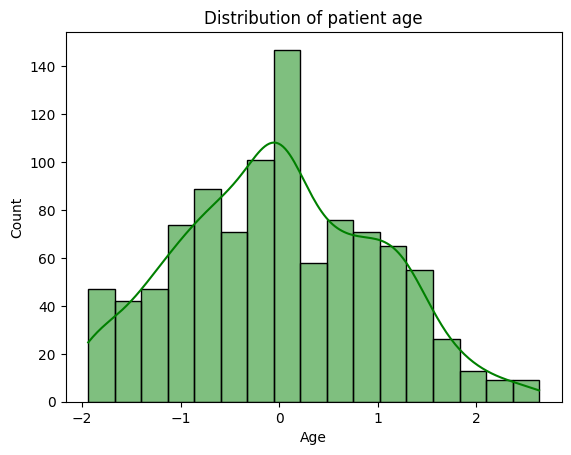

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data["Age"],color = "green" , kde = True)
plt.title("Distribution of patient age")

Text(0.5, 1.0, 'Distribution BMI')

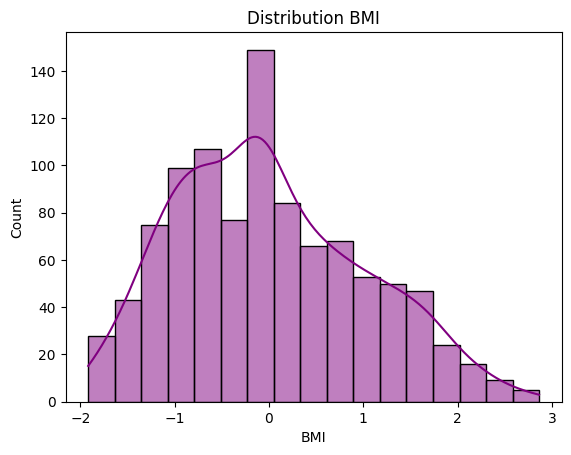

In [13]:
sns.histplot(data["BMI"],color = "purple" , kde = True)
plt.title("Distribution BMI")

<Axes: xlabel='Family History', ylabel='Diabetes Risk'>

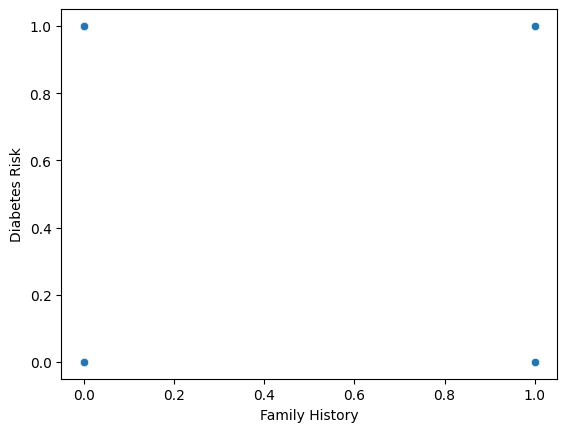

In [14]:
sns.scatterplot(data = data , x = "Family History" , y = "Diabetes Risk")

<Axes: xlabel='Diabetes Risk', ylabel='Physical Activity (hours/week)'>

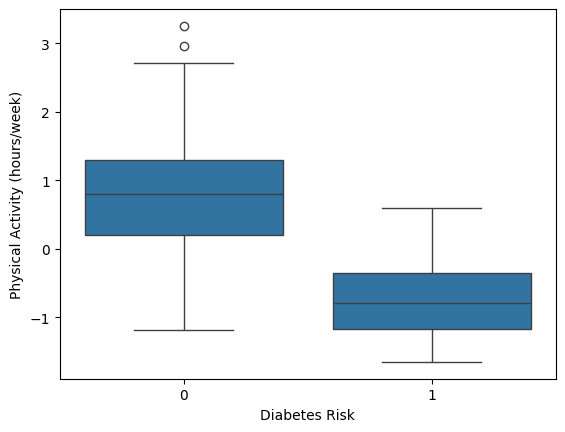

In [15]:
sns.boxplot(data = data , y = "Physical Activity (hours/week)" ,x = "Diabetes Risk")

In [16]:
from sklearn.model_selection import train_test_split
x = data.drop("Diabetes Risk",axis = 1)
y = data["Diabetes Risk"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)
print("classification_report" , classification_report(y_test , lr_y_pred))
print("accuracy_score" , accuracy_score(y_test , lr_y_pred))
print("confusion_matrix" , confusion_matrix(y_test , lr_y_pred))

classification_report               precision    recall  f1-score   support

           0       0.79      0.99      0.88       100
           1       0.99      0.74      0.85       100

    accuracy                           0.86       200
   macro avg       0.89      0.86      0.86       200
weighted avg       0.89      0.86      0.86       200

accuracy_score 0.865
confusion_matrix [[99  1]
 [26 74]]


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
dt = DecisionTreeClassifier()
dt.fit(x_train , y_train)
dt_y_pred = dt.predict(x_test)
print("classification_report" , classification_report(y_test , dt_y_pred))
print("accuracy_score" , accuracy_score(y_test , dt_y_pred))
print("confusion_matrix" , confusion_matrix(y_test , dt_y_pred))

classification_report               precision    recall  f1-score   support

           0       0.96      0.70      0.81       100
           1       0.76      0.97      0.85       100

    accuracy                           0.83       200
   macro avg       0.86      0.83      0.83       200
weighted avg       0.86      0.83      0.83       200

accuracy_score 0.835
confusion_matrix [[70 30]
 [ 3 97]]


<Axes: xlabel='Diabetes Risk'>

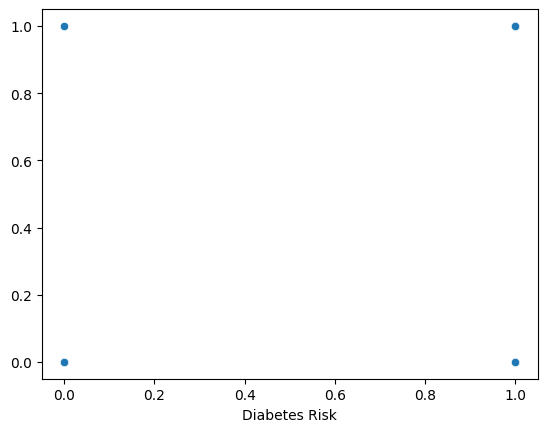

In [19]:
sns.scatterplot(x = y_test , y = lr_y_pred)

In [20]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
grid_params = {
    "max_depth" : [x for x in range(30,80)],
    "max_leaf_nodes" : [x for x in range(50,90)],
}
grid_model = GridSearchCV(DecisionTreeClassifier() , grid_params , cv = 5)
grid_model.fit(x_train , y_train)
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_depth': 39, 'max_leaf_nodes': 89}
0.9675


In [21]:
data.columns

Index(['Age', 'BMI', 'Blood Pressure', 'Physical Activity (hours/week)',
       'Family History', 'Smoking Status', 'Diabetes Risk'],
      dtype='object')

In [22]:
def predict(Age , BMI , Blood_Pressure , Physical_Activity_hours_week , Family_History , Smoking_Status):
    try:
        input_data = pd.DataFrame({
            "Age" : [Age],
            "BMI" : [BMI],
            "Blood Pressure" : [Blood_Pressure],
            "Physical Activity (hours/week)" : [Physical_Activity_hours_week],
            "Family History" : [Family_History],
            "Smoking Status" : [Smoking_Status],
        })
        for col in cat_columns:
            input_data[col] = le[col].transform(input_data[col])
        input_data[num_columns] = scale.transform(input_data[num_columns])
        prediction = dt.predict(input_data)[0]
        return prediction
    except Exception as e:
        return f"error {e}"


In [23]:
import gradio as gr
gr.Interface(
    fn = predict,
    inputs = [
        gr.Number(label = "Age"),
        gr.Number(label = "BMI"),
        gr.Number(label = "Blood Pressure"),
        gr.Number(label = "Physical Activity (hours/week)"),
        gr.Dropdown(label = "Family History" , choices = ["Yes" , "No"]),
        gr.Dropdown(label = "Smoking Status" , choices = ["Yes" , "No"]),
    ],
    outputs = "text",
    title = "predicting Diabetse risk",
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://98f7059a0eb60b9d41.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
